In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.neighbors import  KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, plot_confusion_matrix, confusion_matrix
import pickle

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
DATA_PATH = "/kaggle/working/fertilizer_33000.csv"

## Exploring the Data

In [4]:
data = pd.read_csv(DATA_PATH)
data.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [5]:
data["Fertilizer Name"].unique()

array(['Urea', 'DAP', '14-35-14', '28-28', '17-17-17', '20-20',
       '10-26-26'], dtype=object)

In [6]:
data.shape

(33000, 9)

In [7]:
data["Soil Type"].unique()

array(['Sandy', 'Loamy', 'Black', 'Red', 'Clayey'], dtype=object)

In [8]:
data["Crop Type"].unique()

array(['Maize', 'Sugarcane', 'Cotton', 'Tobacco', 'Paddy', 'Barley',
       'Wheat', 'Millets', 'Oil seeds', 'Pulses', 'Ground Nuts'],
      dtype=object)

In [9]:
data.columns

Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

## Univariate Analysis

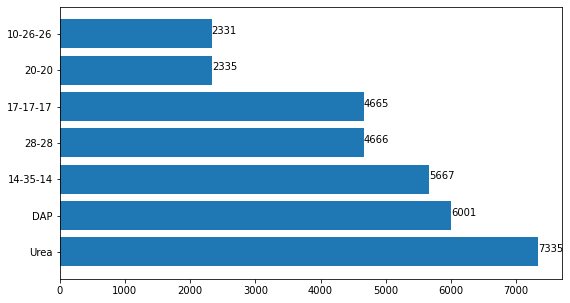

In [10]:
labels = data["Fertilizer Name"].unique()
counts = list(data["Fertilizer Name"].value_counts())

plt.figure(figsize = (9,5))
plt.barh(labels, counts)
  
for index, value in enumerate(counts):
    plt.text(value, index,
             str(value))
plt.show()

<b>Observation: </b>We can notice that the above data is not balanced. We will be balancing the data using Upsampling.

In [11]:
continuous_data_cols = ["Temparature", "Humidity ", "Moisture", "Nitrogen", "Phosphorous"]
categorical_data_cols = ["Soil Type", "Crop Type"]

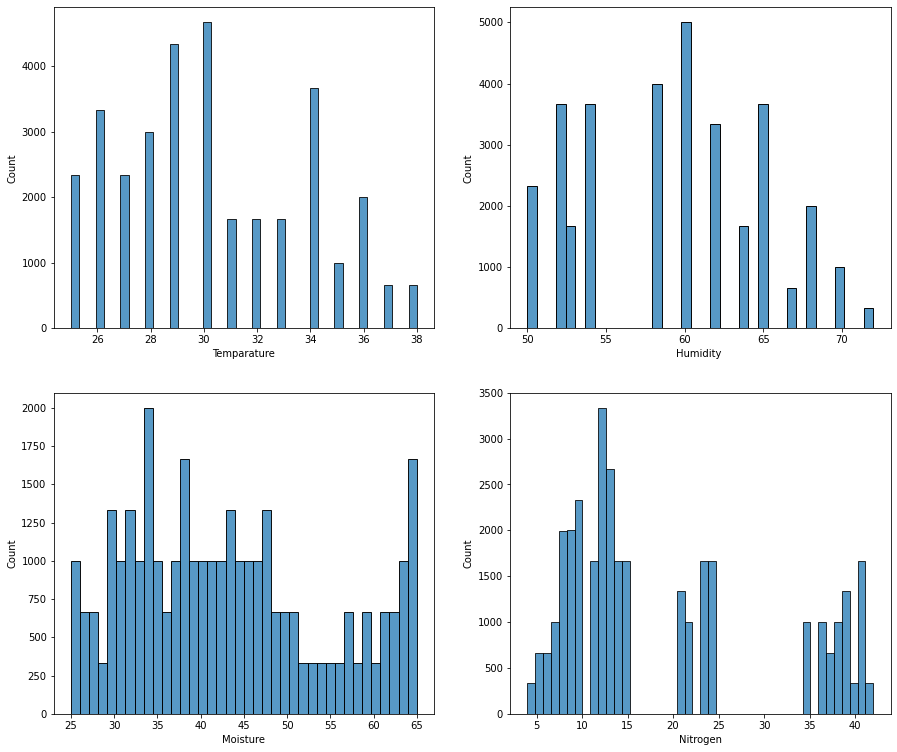

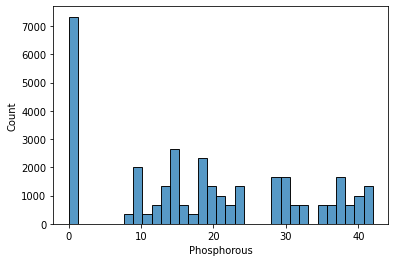

In [12]:
plt.figure(figsize=(15,13))
i = 1
for column in continuous_data_cols[:-1]:
    plt.subplot(2,2,i)
    sns.histplot(data[column])
    i+=1
plt.show()

sns.histplot(data[continuous_data_cols[-1]])
plt.show()

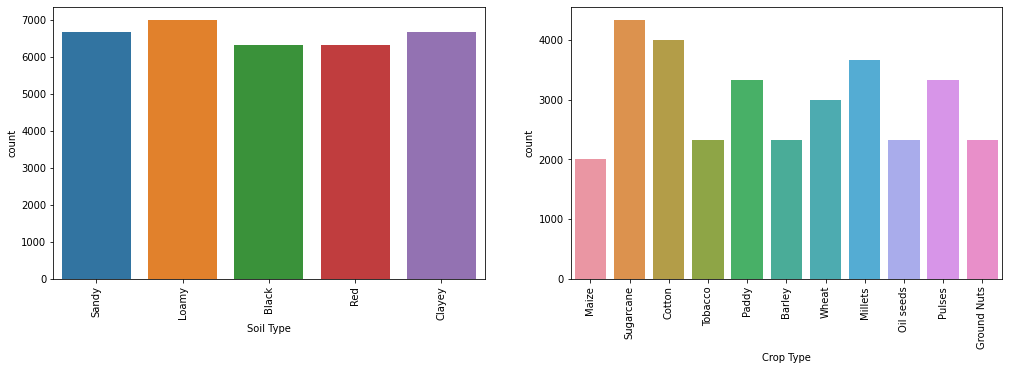

In [13]:
plt.figure(figsize=(17,5))
i = 1
for column in categorical_data_cols:
    plt.subplot(1,2,i)
    sns.countplot(data[column])
    plt.xticks(rotation = 90)
    i+=1
plt.show()

## Bivariate Analysis

<Figure size 1512x1224 with 0 Axes>

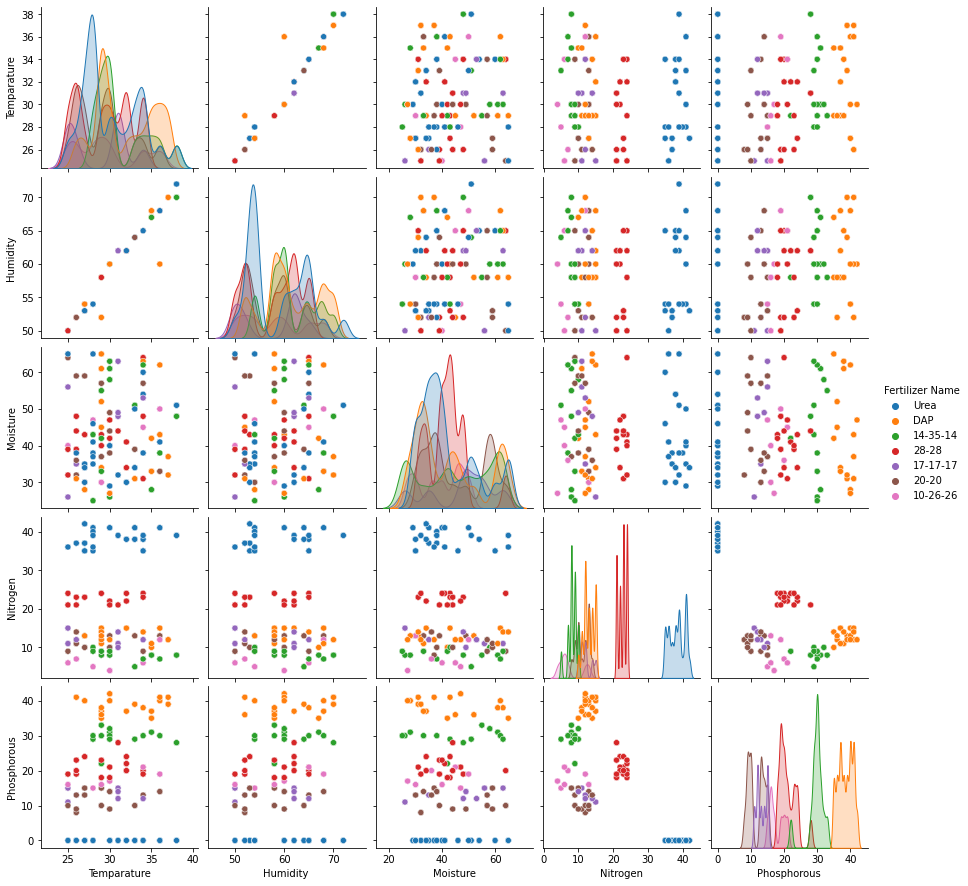

In [14]:
plt.figure(figsize=(21,17))
sns.pairplot(data[continuous_data_cols + ["Fertilizer Name"]], hue = "Fertilizer Name")
plt.show()

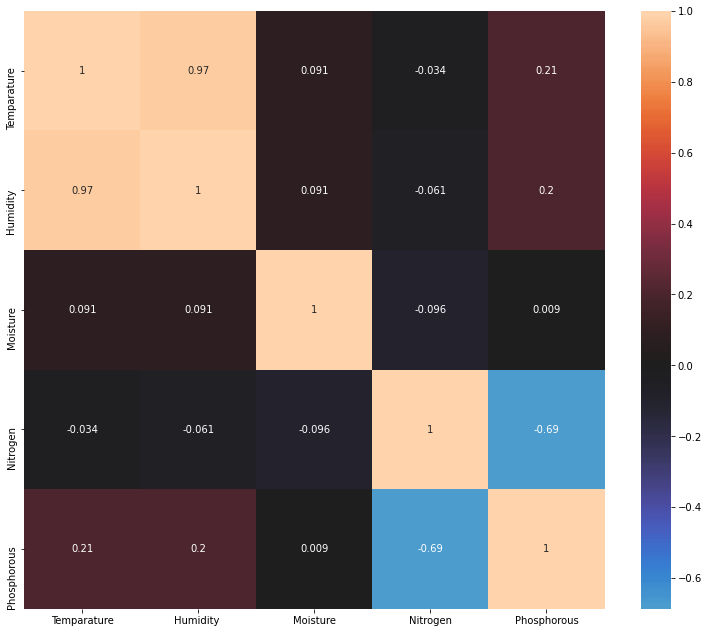

In [15]:
plt.figure(figsize = (13,11))
sns.heatmap(data[continuous_data_cols].corr(), center = 0, annot = True)
plt.show()

In [16]:
soil_type_label_encoder = LabelEncoder()
data["Soil Type"] = soil_type_label_encoder.fit_transform(data["Soil Type"])

In [17]:
crop_type_label_encoder = LabelEncoder()
data["Crop Type"] = crop_type_label_encoder.fit_transform(data["Crop Type"])

In [18]:
croptype_dict = {}
for i in range(len(data["Crop Type"].unique())):
    croptype_dict[i] = crop_type_label_encoder.inverse_transform([i])[0]
print(croptype_dict)

soiltype_dict = {}
for i in range(len(data["Soil Type"].unique())):
    soiltype_dict[i] = soil_type_label_encoder.inverse_transform([i])[0]
print(soiltype_dict)

{0: 'Barley', 1: 'Cotton', 2: 'Ground Nuts', 3: 'Maize', 4: 'Millets', 5: 'Oil seeds', 6: 'Paddy', 7: 'Pulses', 8: 'Sugarcane', 9: 'Tobacco', 10: 'Wheat'}
{0: 'Black', 1: 'Clayey', 2: 'Loamy', 3: 'Red', 4: 'Sandy'}


In [19]:
fertname_label_encoder = LabelEncoder()
data["Fertilizer Name"] = fertname_label_encoder.fit_transform(data["Fertilizer Name"])

In [20]:
fertname_dict = {}
for i in range(len(data["Fertilizer Name"].unique())):
    fertname_dict[i] = fertname_label_encoder.inverse_transform([i])[0]
print(fertname_dict)

{0: '10-26-26', 1: '14-35-14', 2: '17-17-17', 3: '20-20', 4: '28-28', 5: 'DAP', 6: 'Urea'}


In [21]:
data.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,4,3,37,0,0,6
1,29,52,45,2,8,12,0,36,5
2,34,65,62,0,1,7,9,30,1
3,32,62,34,3,9,22,0,20,4
4,28,54,46,1,6,35,0,0,6


In [22]:
X = data[data.columns[:-1]]
y = data[data.columns[-1]]

## Upsampling the Data

In [23]:
counter = Counter(y)
counter

Counter({6: 7335, 5: 6001, 1: 4665, 4: 5667, 2: 2335, 3: 4666, 0: 2331})

In [24]:
upsample = SMOTE()
X, y = upsample.fit_resample(X, y)
counter = Counter(y)
print(counter)

Counter({6: 7335, 5: 7335, 1: 7335, 4: 7335, 2: 7335, 3: 7335, 0: 7335})


In [25]:
print(f"Total Data after Upsampling: {len(X)}")

Total Data after Upsampling: 51345


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size = 0.2, random_state = 0)
print(f"Train Data: {X_train.shape}, {y_train.shape}")
print(f"Train Data: {X_test.shape}, {y_test.shape}")

Train Data: (41076, 8), (41076,)
Train Data: (10269, 8), (10269,)


## KNN Classifier

Accuracy at k = 1 is 1.0
Accuracy at k = 2 is 1.0
Accuracy at k = 3 is 1.0
Accuracy at k = 4 is 1.0
Accuracy at k = 5 is 1.0
Accuracy at k = 6 is 1.0
Accuracy at k = 7 is 1.0
Accuracy at k = 8 is 1.0
Accuracy at k = 9 is 1.0
Accuracy at k = 10 is 1.0
Accuracy at k = 11 is 1.0
Accuracy at k = 12 is 1.0
Accuracy at k = 13 is 1.0
Accuracy at k = 14 is 1.0
Accuracy at k = 15 is 1.0
Accuracy at k = 16 is 1.0
Accuracy at k = 17 is 1.0
Accuracy at k = 18 is 1.0
Accuracy at k = 19 is 1.0
Accuracy at k = 20 is 1.0
Accuracy at k = 21 is 1.0
Accuracy at k = 22 is 1.0
Accuracy at k = 23 is 1.0
Accuracy at k = 24 is 1.0
Accuracy at k = 25 is 1.0
Accuracy at k = 26 is 1.0
Accuracy at k = 27 is 1.0
Accuracy at k = 28 is 1.0
Accuracy at k = 29 is 1.0
Accuracy at k = 30 is 1.0
Accuracy at k = 31 is 1.0
Accuracy at k = 32 is 1.0
Accuracy at k = 33 is 1.0
Accuracy at k = 34 is 1.0
Accuracy at k = 35 is 1.0
Accuracy at k = 36 is 1.0
Accuracy at k = 37 is 1.0
Accuracy at k = 38 is 1.0
Accuracy at k = 39 is

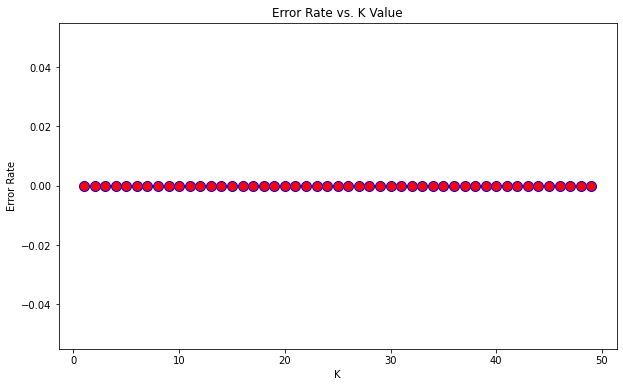

In [27]:
error_rate = []
for i in range(1, 50):
    pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors = i))
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy at k = {i} is {accuracy}")
    error_rate.append(np.mean(predictions != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,50),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate))+1)

## SVM Classifier

Accuracy on Test Data: 100.0%


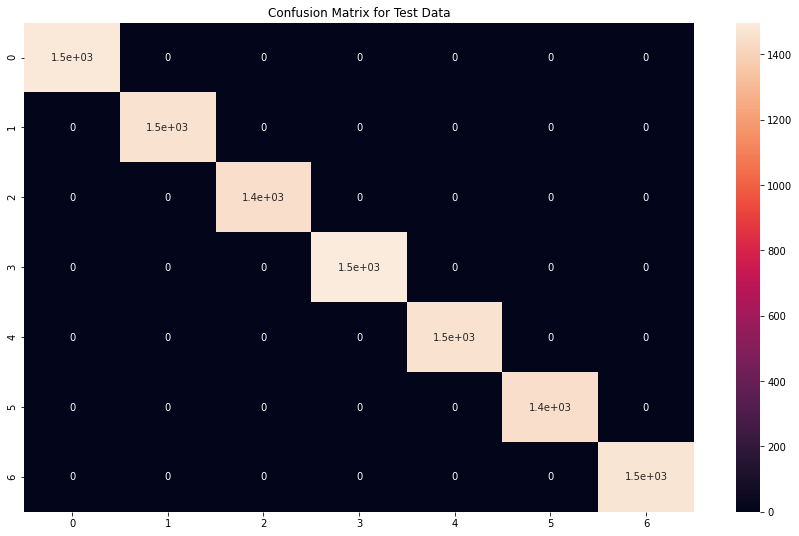


Accuracy on Whole Data: 100.0%


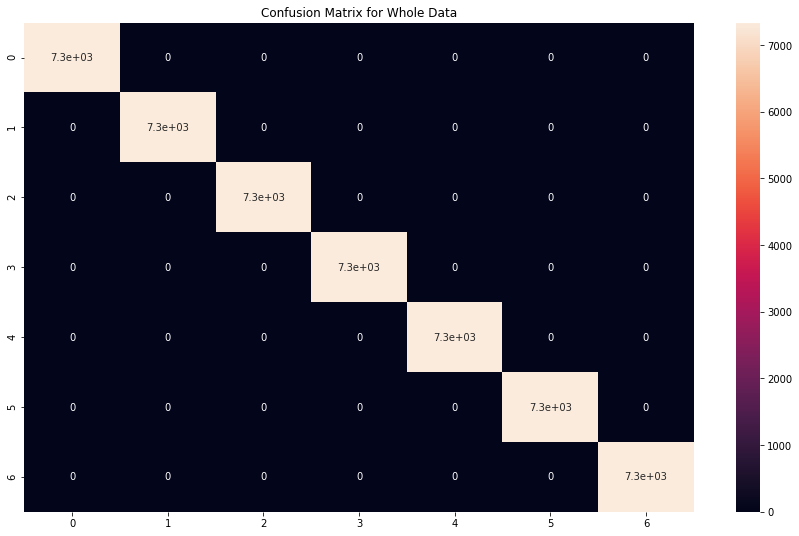

In [28]:
svm_pipeline = make_pipeline(StandardScaler(), SVC(probability=True))
svm_pipeline.fit(X_train, y_train)

# Accuray On Test Data
predictions = svm_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on Test Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y_test, predictions), annot = True)
plt.title("Confusion Matrix for Test Data")
plt.show()

print()

# Accuray On Whole Data
predictions = svm_pipeline.predict(X.values)
accuracy = accuracy_score(y, predictions)
print(f"Accuracy on Whole Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y, predictions), annot = True)
plt.title("Confusion Matrix for Whole Data")
plt.show()

## Random Forest Classifier

Accuracy on Test Data: 100.0%


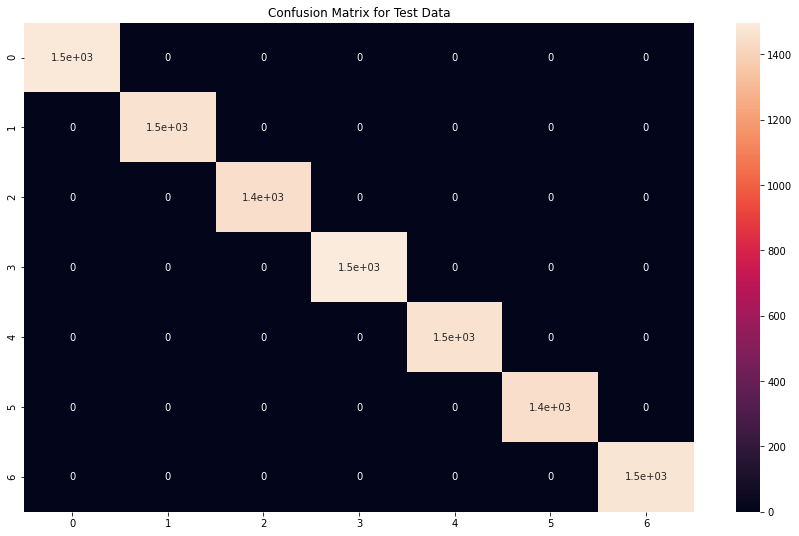


Accuracy on Whole Data: 100.0%


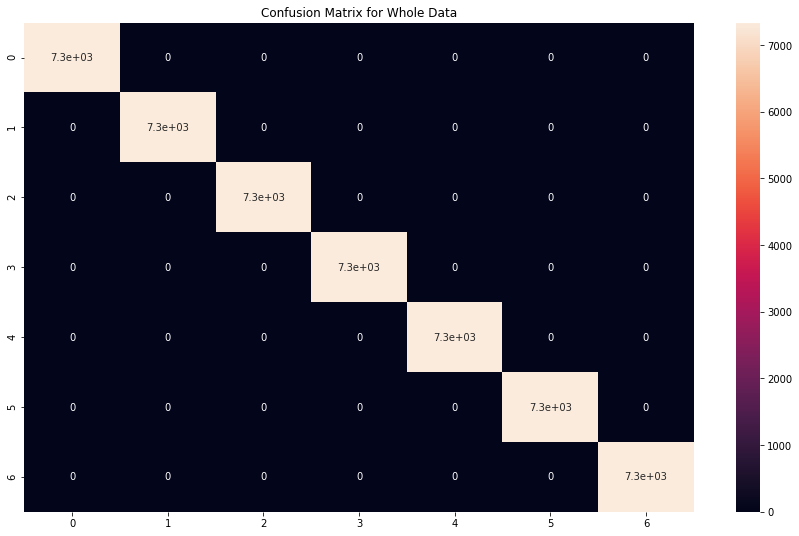

In [29]:
rf_pipeline = make_pipeline(StandardScaler(), RandomForestClassifier(random_state = 18))
rf_pipeline.fit(X_train, y_train)

# Accuray On Test Data
predictions = rf_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on Test Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y_test, predictions), annot = True)
plt.title("Confusion Matrix for Test Data")
plt.show()

print()

# Accuray On Whole Data
predictions = rf_pipeline.predict(X.values)
accuracy = accuracy_score(y, predictions)
print(f"Accuracy on Whole Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y, predictions), annot = True)
plt.title("Confusion Matrix for Whole Data")
plt.show()

## XGBoost Classifier

[17:02:35] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy on Test Data: 100.0%


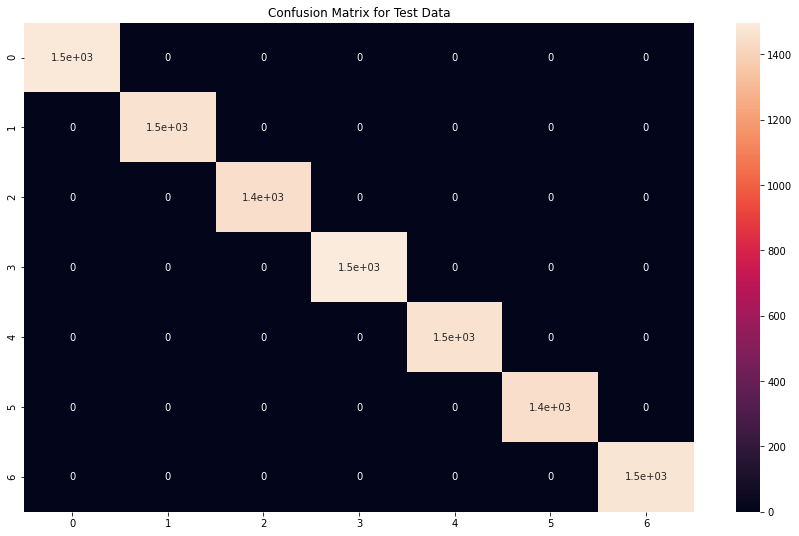


Accuracy on Whole Data: 100.0%


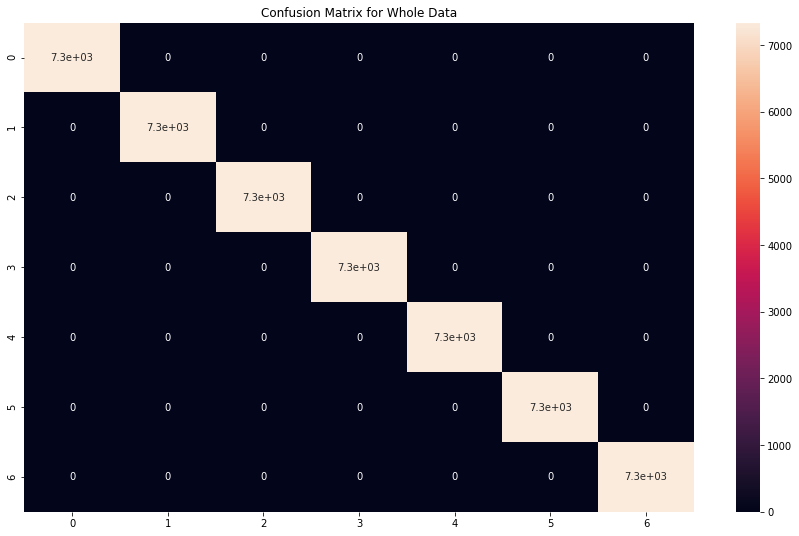

In [30]:
xgb_pipeline = make_pipeline(StandardScaler(), XGBClassifier(random_state = 18))
xgb_pipeline.fit(X_train, y_train)

# Accuray On Test Data
predictions = xgb_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on Test Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y_test, predictions), annot = True)
plt.title("Confusion Matrix for Test Data")
plt.show()

print()

# Accuray On Whole Data
predictions = xgb_pipeline.predict(X.values)
accuracy = accuracy_score(y, predictions)
print(f"Accuracy on Whole Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y, predictions), annot = True)
plt.title("Confusion Matrix for Whole Data")
plt.show()

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# -------------------------
# 1. Define New Pipelines
# -------------------------

logreg_pipeline = Pipeline([
    ('model', LogisticRegression(max_iter=1000))
])

knn_pipeline = Pipeline([
    ('model', KNeighborsClassifier(n_neighbors=5))
])

dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])


# -------------------------
# 2. Train Models
# -------------------------

logreg_pipeline.fit(X_train, y_train)
knn_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)


# -------------------------
# 3. Save Models (Optional)
# -------------------------

import joblib



In [32]:
import joblib

joblib.dump(svm_pipeline, "svm_pipeline.joblib")
joblib.dump(rf_pipeline, "rf_pipeline.joblib")
joblib.dump(xgb_pipeline, "xgb_pipeline.joblib")
joblib.dump(fertname_dict, "fertname_dict.joblib")
joblib.dump(croptype_dict, "croptype_dict.joblib")
joblib.dump(soiltype_dict, "soiltype_dict.joblib")
joblib.dump(logreg_pipeline, "logreg_pipeline.joblib")
joblib.dump(knn_pipeline, "knn_pipeline.joblib")
joblib.dump(dt_pipeline, "dt_pipeline.joblib")

['dt_pipeline.joblib']

In [33]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)

# -------------------------
# 1. Load Models
# -------------------------
svm_pipeline = joblib.load("svm_pipeline.joblib")
rf_pipeline = joblib.load("rf_pipeline.joblib")
xgb_pipeline = joblib.load("xgb_pipeline.joblib")

# -------------------------
# 2. Function to Calculate Metrics
# -------------------------
def calculate_metrics(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Not valid for multi-class → set safely
    specificity = 0
    fpr = 0
    fnr = 0

    error_rate = 1 - accuracy

    # ROC-AUC for multi-class
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except:
        roc_auc = 0

    mcc = matthews_corrcoef(y_true, y_pred)

    return accuracy, precision, recall, f1, specificity, error_rate, roc_auc, fpr, fnr, mcc
# -------------------------
# 3. Store Results
# -------------------------
model_results = []

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # For probability (needed for ROC-AUC)
    try:
        y_prob = model.predict_proba(X_test)
    except:
        y_prob = None

    metrics = calculate_metrics(y_test, y_pred, y_prob)

    (accuracy, precision, recall, f1, specificity,
     error_rate, roc_auc, fpr, fnr, mcc) = metrics

    model_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity,
        "Error Rate": error_rate,
        "ROC-AUC": roc_auc,
        "FPR": fpr,
        "FNR": fnr,
        "MCC": mcc
    })


# -------------------------
# 4. Run Evaluation (IMPORTANT: You must have X_test, y_test)
# -------------------------

# 👉 Make sure these exist in your notebook
# X_test, y_test

evaluate_model("SVM", svm_pipeline, X_test, y_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test)
evaluate_model("XGBoost", xgb_pipeline, X_test, y_test)
evaluate_model("Logistic Regression", logreg_pipeline, X_test, y_test)
evaluate_model("KNN", knn_pipeline, X_test, y_test)
evaluate_model("Decision Tree", dt_pipeline, X_test, y_test)

# -------------------------
# 5. Create Comparative Table
# -------------------------
comparison_df = pd.DataFrame(model_results)

if comparison_df.empty:
    print("❌ No data available. Check model evaluation.")
else:
    comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

    print("\n🔥 Final Comparative Table:")
    print(comparison_df)


# -------------------------
# 6. Best Model
# -------------------------
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("\n🏆 Best Model:")
print(best_model[["Model", "Accuracy"]])


🔥 Final Comparative Table:
                 Model  Accuracy  Precision  Recall  F1-Score  Specificity  \
0                  SVM       1.0        1.0     1.0       1.0            0   
1        Random Forest       1.0        1.0     1.0       1.0            0   
2              XGBoost       1.0        1.0     1.0       1.0            0   
3  Logistic Regression       1.0        1.0     1.0       1.0            0   
4                  KNN       1.0        1.0     1.0       1.0            0   
5        Decision Tree       1.0        1.0     1.0       1.0            0   

   Error Rate  ROC-AUC  FPR  FNR  MCC  
0         0.0      1.0    0    0  1.0  
1         0.0      1.0    0    0  1.0  
2         0.0      1.0    0    0  1.0  
3         0.0      1.0    0    0  1.0  
4         0.0      1.0    0    0  1.0  
5         0.0      1.0    0    0  1.0  

🏆 Best Model:
Model       SVM
Accuracy    1.0
Name: 0, dtype: object
